# Effectiveness of AI in Computer Science #

## Importing Libraries

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb as ddb

- Pandas: for reading CSV file and exploratory analysis.
- Matplotlib & Seaborn: for visualization.
- DuckDB: for SQL querying if needed.

In [66]:
import os
print("Files Docker can see right now:")
print(os.listdir('.'))

Files Docker can see right now:
['ai_cs_analysis.ipynb', 'charts', '.git', '.devcontainer', 'Dockerfile', 'survey_results_public.csv', 'README.md', '.gitignore']


Using `os.listdir` to check what files in the project repository does Docker can see.

## Import and analyze the data

For this project, we used the 2025 Stack Overflow Developer Survey to reference the use of AI by developers around the world.

In [67]:
data = pd.read_csv(r'survey_results_public.csv')
data.head(5)

/tmp/ipykernel_1179/2543645080.py:1: DtypeWarning: Columns (0: JobSatPoints_15_TEXT, 1: DatabaseHaveEntry, 2: DevEnvHaveEntry, 3: SOTagsHaveEntry, 4: SOTagsWant Entry, 5: OfficeStackWantEntry, 6: CommPlatformHaveEntr, 7: CommPlatformWantEntr, 8: SO_Actions_15_TEXT, 9: AIAgentOrchestration, 10: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r'survey_results_public.csv')


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


### Exploratory Data Analysis

In [68]:
data.columns

Index(['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment',
       'EmploymentAddl', 'WorkExp', 'LearnCodeChoose', 'LearnCode',
       'LearnCodeAI',
       ...
       'AIAgentOrchestration', 'AIAgentOrchWrite', 'AIAgentObserveSecure',
       'AIAgentObsWrite', 'AIAgentExternal', 'AIAgentExtWrite', 'AIHuman',
       'AIOpen', 'ConvertedCompYearly', 'JobSat'],
      dtype='str', length=172)

The survey has 172 column attributes, so reducing the dimension for the most relevant ones would be necessary.

In [69]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), str(119)
memory usage: 64.6 MB


In [70]:
data.isnull().sum()

ResponseId                 0
MainBranch                 0
Age                        0
EdLevel                 1042
Employment               852
                       ...  
AIAgentExtWrite        48332
AIHuman                19997
AIOpen                 26651
ConvertedCompYearly    25244
JobSat                 22521
Length: 172, dtype: int64

In [71]:
data.describe()

,ResponseId,WorkExp,YearsCode,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,...,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,ConvertedCompYearly,JobSat
count,49191.000000,42893.000000,43042.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,...,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,2.394700e+04,26670.000000
mean,24596.000000,13.367403,16.570861,7.867352,4.104211,4.110271,5.678193,4.119388,5.225990,6.477387,...,5.718355,4.561767,4.790861,5.199657,5.676314,4.984653,7.099505,10.079284,1.017615e+05,7.201950
std,14200.362883,10.800117,11.787610,2.397432,2.275821,2.329536,2.398084,2.437945,2.801045,2.331468,...,2.628016,3.070548,2.643177,2.563562,2.310659,2.490095,2.469394,1.940928,4.617569e+05,1.997245
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,0.000000
25%,12298.500000,5.000000,8.000000,7.000000,2.000000,2.000000,4.000000,2.000000,3.000000,5.000000,...,3.000000,1.000000,3.000000,3.000000,4.000000,3.000000,6.000000,10.000000,3.817100e+04,6.000000
50%,24596.000000,10.000000,14.000000,9.000000,4.000000,4.000000,6.000000,4.000000,5.000000,7.000000,...,6.000000,4.000000,5.000000,5.000000,6.000000,5.000000,8.000000,10.000000,7.532000e+04,8.000000
75%,36893.500000,20.000000,24.000000,9.000000,6.000000,6.000000,8.000000,6.000000,8.000000,8.000000,...,8.000000,7.000000,7.000000,7.000000,7.000000,7.000000,9.000000,10.000000,1.205960e+05,8.000000
max,49191.000000,100.000000,100.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,...,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,5.000000e+07,10.000000


In [72]:
demog_ai = data[['MainBranch', 'Age', 'EdLevel', 'YearsCode', 'Industry', 'LearnCodeAI', 'AILearnHow', 'AISelect', 'AISent', 'AIAcc', 'AIComplex']]
demog_ai.head(5)

,MainBranch,Age,EdLevel,YearsCode,Industry,LearnCodeAI,AILearnHow,AISelect,AISent,AIAcc,AIComplex
0,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,Fintech,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,"Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,Bad at handling complex tasks
1,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",10.0,Retail and Consumer Services,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,"Yes, I use AI tools weekly",Indifferent,Neither trust nor distrust,Bad at handling complex tasks
2,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,Software Development,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Technical ...,"Yes, I use AI tools daily",Favorable,Somewhat trust,Neither good or bad at handling complex tasks
3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,Retail and Consumer Services,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Videos (no...,"Yes, I use AI tools weekly",Favorable,Somewhat trust,Bad at handling complex tasks
4,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,Software Development,"Yes, I learned how to use AI-enabled tools for...",Technical documentation (is generated for/by t...,"Yes, I use AI tools weekly",Favorable,Neither trust nor distrust,"Good, but not great at handling complex tasks"


In [73]:
demog_ai['YearsCode'].describe()

count    43042.000000
mean        16.570861
std         11.787610
min          1.000000
25%          8.000000
50%         14.000000
75%         24.000000
max        100.000000
Name: YearsCode, dtype: float64

In [74]:
demog_ai.info()

<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MainBranch   49191 non-null  str    
 1   Age          49191 non-null  str    
 2   EdLevel      48149 non-null  str    
 3   YearsCode    43042 non-null  float64
 4   Industry     33642 non-null  str    
 5   LearnCodeAI  45201 non-null  str    
 6   AILearnHow   28257 non-null  str    
 7   AISelect     33720 non-null  str    
 8   AISent       33467 non-null  str    
 9   AIAcc        33297 non-null  str    
 10  AIComplex    33283 non-null  str    
dtypes: float64(1), str(10)
memory usage: 4.1 MB


In [75]:
demog_ai.dtypes

MainBranch         str
Age                str
EdLevel            str
YearsCode      float64
Industry           str
LearnCodeAI        str
AILearnHow         str
AISelect           str
AISent             str
AIAcc              str
AIComplex          str
dtype: object

In [76]:
demog_ai.columns

Index(['MainBranch', 'Age', 'EdLevel', 'YearsCode', 'Industry', 'LearnCodeAI',
       'AILearnHow', 'AISelect', 'AISent', 'AIAcc', 'AIComplex'],
      dtype='str')

In [77]:
demog_ai['AILearnHow'].value_counts()

AILearnHow
AI CodeGen tools or AI-enabled apps                                                                                                                                                                                                                           2555
Other online resources (e.g. standard search, forum, online community)                                                                                                                                                                                         991
Colleague or on-the-job training                                                                                                                                                                                                                               777
Videos (not associated with specific online course or certification)                                                                                                                                                

In [78]:
demog_ai.isnull().sum()

MainBranch         0
Age                0
EdLevel         1042
YearsCode       6149
Industry       15549
LearnCodeAI     3990
AILearnHow     20934
AISelect       15471
AISent         15724
AIAcc          15894
AIComplex      15908
dtype: int64

In [79]:
demog_ai.head(5)

,MainBranch,Age,EdLevel,YearsCode,Industry,LearnCodeAI,AILearnHow,AISelect,AISent,AIAcc,AIComplex
0,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,Fintech,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,"Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,Bad at handling complex tasks
1,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",10.0,Retail and Consumer Services,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,"Yes, I use AI tools weekly",Indifferent,Neither trust nor distrust,Bad at handling complex tasks
2,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,Software Development,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Technical ...,"Yes, I use AI tools daily",Favorable,Somewhat trust,Neither good or bad at handling complex tasks
3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,Retail and Consumer Services,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Videos (no...,"Yes, I use AI tools weekly",Favorable,Somewhat trust,Bad at handling complex tasks
4,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,Software Development,"Yes, I learned how to use AI-enabled tools for...",Technical documentation (is generated for/by t...,"Yes, I use AI tools weekly",Favorable,Neither trust nor distrust,"Good, but not great at handling complex tasks"


In [80]:
demog_ai['Age'].value_counts()

Age
25-34 years old      16519
35-44 years old      13241
18-24 years old       9210
45-54 years old       6275
55-64 years old       2626
65 years or older      942
Prefer not to say      378
Name: count, dtype: int64

In [81]:
age_sort = ['18-24', '25-34', '35-44', '45-54', '55-64', '65 or older', 'Prefer not to say']

In [82]:
# Map the raw survey responses to your exact desired labels
age_mapping = {
    '18-24 years old': '18-24',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',
    '45-54 years old': '45-54',
    '55-64 years old': '55-64',
    '65 years or older': '65 or older',
    'Prefer not to say': 'Prefer not to say'
}

demog_ai['Age'] = demog_ai['Age'].replace(age_mapping)
demog_ai.head(5)

,MainBranch,Age,EdLevel,YearsCode,Industry,LearnCodeAI,AILearnHow,AISelect,AISent,AIAcc,AIComplex
0,I am a developer by profession,25-34,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,Fintech,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,"Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,Bad at handling complex tasks
1,I am a developer by profession,25-34,"Associate degree (A.A., A.S., etc.)",10.0,Retail and Consumer Services,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,"Yes, I use AI tools weekly",Indifferent,Neither trust nor distrust,Bad at handling complex tasks
2,I am a developer by profession,35-44,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,Software Development,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Technical ...,"Yes, I use AI tools daily",Favorable,Somewhat trust,Neither good or bad at handling complex tasks
3,I am a developer by profession,35-44,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,Retail and Consumer Services,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Videos (no...,"Yes, I use AI tools weekly",Favorable,Somewhat trust,Bad at handling complex tasks
4,I am a developer by profession,35-44,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,Software Development,"Yes, I learned how to use AI-enabled tools for...",Technical documentation (is generated for/by t...,"Yes, I use AI tools weekly",Favorable,Neither trust nor distrust,"Good, but not great at handling complex tasks"


In [83]:
# 1. Apply the mapping using .replace()
# 2. Chain the value_counts and formatting logic
age_groups = (demog_ai['Age']
              .replace(age_mapping)
              .value_counts(normalize=True)
              .mul(100)
              .round(2)
              .reset_index())

# Rename the columns
age_groups.columns = ['Age_Group', 'Proportion']

# Set the index and reindex using your age_sort list
age_groups = age_groups.set_index('Age_Group')
age_groups = age_groups.reindex(age_sort)

age_groups

,Proportion
Age_Group,
18-24,18.72
25-34,33.58
35-44,26.92
45-54,12.76
55-64,5.34
65 or older,1.91
Prefer not to say,0.77


In [84]:
demog_ai.dtypes

MainBranch         str
Age                str
EdLevel            str
YearsCode      float64
Industry           str
LearnCodeAI        str
AILearnHow         str
AISelect           str
AISent             str
AIAcc              str
AIComplex          str
dtype: object

In [85]:
demog_ai['Industry'].isna().sum()

np.int64(15549)

In [86]:
demog_ai['Industry'] = demog_ai['Industry'].str.split(':').str[0].str.strip()

industry_filtered = demog_ai[demog_ai['Industry'].notna()]
industry = pd.DataFrame(industry_filtered['Industry'].value_counts(normalize=True).mul(100).round(2).reset_index())
industry.columns = ['Industry', 'Proportion']
industry

,Industry,Proportion
0,Software Development,48.40
1,Other,7.93
2,"Internet, Telecomm or Information Services",5.05
3,Fintech,5.02
4,Banking/Financial Services,4.27
5,Healthcare,4.15
6,Manufacturing,3.91
7,Government,3.52
8,Higher Education,3.47
9,Retail and Consumer Services,3.13


In [87]:
learn_code = pd.DataFrame(demog_ai['LearnCodeAI'].value_counts(normalize=True).mul(100).round(2)).reset_index()
learn_code

,LearnCodeAI,proportion
0,"Yes, I learned how to use AI-enabled tools req...",36.29
1,"Yes, I learned how to use AI-enabled tools for...",31.03
2,"No, I learned something that was not related t...",11.69
3,"No, I didn't spend time learning in the past year",10.76
4,"No, I learned something that was not related t...",10.23


In [88]:
learn_code_ai_mapping = {
    'Yes, I learned how to use AI-enabled tools required for my job or to benefit my career': 'Required and benefit for job/career',
    'Yes, I learned how to use AI-enabled tools for my personal curiosity and/or hobbies': 'Personal curiosity/hobbies',
    "No, I learned something that was not related to AI or AI enablement for my personal curiosity and/or hobbies": "Didn't learn AI related or AI enablement",
    "No, I didn't spend time learning in the past year": "Didn't learn AI related or AI enablement",
    "No, I learned something that was not related to AI or AI enablement as required for my job or to benefit my career": "Didn't learn AI related or AI enablement"
}

demog_ai['LearnCodeAI'] = demog_ai['LearnCodeAI'].replace(learn_code_ai_mapping)
demog_ai.head(5)

,MainBranch,Age,EdLevel,YearsCode,Industry,LearnCodeAI,AILearnHow,AISelect,AISent,AIAcc,AIComplex
0,I am a developer by profession,25-34,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,Fintech,Personal curiosity/hobbies,AI CodeGen tools or AI-enabled apps,"Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,Bad at handling complex tasks
1,I am a developer by profession,25-34,"Associate degree (A.A., A.S., etc.)",10.0,Retail and Consumer Services,Personal curiosity/hobbies,AI CodeGen tools or AI-enabled apps,"Yes, I use AI tools weekly",Indifferent,Neither trust nor distrust,Bad at handling complex tasks
2,I am a developer by profession,35-44,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,Software Development,Personal curiosity/hobbies,AI CodeGen tools or AI-enabled apps;Technical ...,"Yes, I use AI tools daily",Favorable,Somewhat trust,Neither good or bad at handling complex tasks
3,I am a developer by profession,35-44,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,Retail and Consumer Services,Personal curiosity/hobbies,AI CodeGen tools or AI-enabled apps;Videos (no...,"Yes, I use AI tools weekly",Favorable,Somewhat trust,Bad at handling complex tasks
4,I am a developer by profession,35-44,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,Software Development,Personal curiosity/hobbies,Technical documentation (is generated for/by t...,"Yes, I use AI tools weekly",Favorable,Neither trust nor distrust,"Good, but not great at handling complex tasks"


In [89]:
new_learn_code = pd.DataFrame(demog_ai['LearnCodeAI'].value_counts(normalize=True).mul(100).round(2)).reset_index()
new_learn_code.columns = ['LearnCodeAI', 'Proportion']
new_learn_code

,LearnCodeAI,Proportion
0,Required and benefit for job/career,36.29
1,Didn't learn AI related or AI enablement,32.68
2,Personal curiosity/hobbies,31.03


In [90]:
ai_select = pd.DataFrame(demog_ai['AISelect'].value_counts(normalize=True).mul(100).round(2))
ai_select

,proportion
AISelect,
"Yes, I use AI tools daily",47.10
"Yes, I use AI tools weekly",17.67
"No, and I don't plan to",16.17
"Yes, I use AI tools monthly or infrequently",13.72
"No, but I plan to soon",5.33


In [91]:
ai_select_mapping = {
    'Yes, I use AI tools daily': 'Daily',
    'Yes, I use AI tools weekly': 'Weekly',
    'Yes, I use AI tools monthly or infrequently': 'Monthly or infrequently',
    "No, and I don't plan to": 'Not plan to use AI tools',
    'No, but I plan to soon': 'Plan to use AI tools soon',
}

demog_ai['AISelect'] = demog_ai['AISelect'].replace(ai_select_mapping)
demog_ai.head(5)

,MainBranch,Age,EdLevel,YearsCode,Industry,LearnCodeAI,AILearnHow,AISelect,AISent,AIAcc,AIComplex
0,I am a developer by profession,25-34,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,Fintech,Personal curiosity/hobbies,AI CodeGen tools or AI-enabled apps,Monthly or infrequently,Indifferent,Neither trust nor distrust,Bad at handling complex tasks
1,I am a developer by profession,25-34,"Associate degree (A.A., A.S., etc.)",10.0,Retail and Consumer Services,Personal curiosity/hobbies,AI CodeGen tools or AI-enabled apps,Weekly,Indifferent,Neither trust nor distrust,Bad at handling complex tasks
2,I am a developer by profession,35-44,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,Software Development,Personal curiosity/hobbies,AI CodeGen tools or AI-enabled apps;Technical ...,Daily,Favorable,Somewhat trust,Neither good or bad at handling complex tasks
3,I am a developer by profession,35-44,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,Retail and Consumer Services,Personal curiosity/hobbies,AI CodeGen tools or AI-enabled apps;Videos (no...,Weekly,Favorable,Somewhat trust,Bad at handling complex tasks
4,I am a developer by profession,35-44,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,Software Development,Personal curiosity/hobbies,Technical documentation (is generated for/by t...,Weekly,Favorable,Neither trust nor distrust,"Good, but not great at handling complex tasks"


In [92]:
ai_select_new = pd.DataFrame(demog_ai['AISelect'].value_counts(normalize=True).mul(100).round(2)).reset_index()
ai_select_new.columns = ['AISelect', 'Proportion']
ai_select_new

,AISelect,Proportion
0,Daily,47.10
1,Weekly,17.67
2,Not plan to use AI tools,16.17
3,Monthly or infrequently,13.72
4,Plan to use AI tools soon,5.33


In [93]:
ai_sent = pd.DataFrame(demog_ai['AISent'].value_counts(normalize=True).mul(100).round(2)).reset_index()
ai_sent.columns = ['AISent', 'Proportion']
ai_sent

,AISent,Proportion
0,Favorable,36.79
1,Very favorable,22.94
2,Indifferent,17.57
3,Unfavorable,10.82
4,Very unfavorable,9.62
5,Unsure,2.27


In [94]:
ai_acc = pd.DataFrame(demog_ai['AIAcc'].value_counts(normalize=True).mul(100).round(2)).reset_index()
ai_acc.columns = ['AIAcc', 'Proportion']
ai_acc

,AIAcc,Proportion
0,Somewhat trust,29.64
1,Somewhat distrust,26.08
2,Neither trust nor distrust,21.51
3,Highly distrust,19.62
4,Highly trust,3.15


In [95]:
demog_ai['AIComplex'].value_counts()

AIComplex
Good, but not great at handling complex tasks            8384
Bad at handling complex tasks                            7328
Very poor at handling complex tasks                      5844
I don't use AI tools for complex tasks / I don't know    5582
Neither good or bad at handling complex tasks            4688
Very well at handling complex tasks                      1457
Name: count, dtype: int64

In [96]:
ai_complex_mapping = {
    'Very well at handling complex tasks': 'Very well',
    'Good, but not great at handling complex tasks': 'Good, but not great',
    'Neither good or bad at handling complex tasks': 'Neither good nor bad',
    'Bad at handling complex tasks': 'Bad',
    'Very poor at handling complex tasks': 'Very poor',
    "I don't use AI tools for complex tasks / I don't know": "Don't use AI tools for complex tasks / Don't know"
}

demog_ai['AIComplex'] = demog_ai['AIComplex'].replace(ai_complex_mapping)

In [97]:
ai_complex = pd.DataFrame(demog_ai['AIComplex'].value_counts(normalize=True).mul(100).round(2)).reset_index()
ai_complex.columns = ['AIComplex', 'Proportion']
ai_complex

,AIComplex,Proportion
0,"Good, but not great",25.19
1,Bad,22.02
2,Very poor,17.56
3,Don't use AI tools for complex tasks / Don't know,16.77
4,Neither good nor bad,14.09
5,Very well,4.38


In [98]:
main_branch = pd.DataFrame(demog_ai['MainBranch'].value_counts(normalize=True).mul(100).round(2)).reset_index()
main_branch.columns = ['MainBranch', 'Proportion']
main_branch

,MainBranch,Proportion
0,I am a developer by profession,76.17
1,"I am not primarily a developer, but I write co...",9.95
2,I am learning to code,5.26
3,I code primarily as a hobby,3.91
4,"I used to be a developer by profession, but no...",2.69
5,I work with developers or my work supports dev...,2.02


In [99]:
main_branch_mapping = {
    'I am a developer by profession': 'Developer by profession',
    'I am not primarily a developer, but I write code sometimes as part of my work/studies': 'Coding as part of work/studies',
    'I am learning to code': 'Learning to code',
    'I code primarily as a hobby': 'Coding as a hobby',
    'I used to be a developer by profession, but no longer am': 'Used to be a developer',
    'I work with developers or my work supports developers but am not a developer by profession': 'Work with/support developers but not a developer'
}

demog_ai['MainBranch'] = demog_ai['MainBranch'].replace(main_branch_mapping)

main_branch_new = pd.DataFrame(demog_ai['MainBranch'].value_counts(normalize=True).mul(100).round(2)).reset_index()
main_branch_new.columns = ['MainBranch', 'Proportion']
main_branch_new

,MainBranch,Proportion
0,Developer by profession,76.17
1,Coding as part of work/studies,9.95
2,Learning to code,5.26
3,Coding as a hobby,3.91
4,Used to be a developer,2.69
5,Work with/support developers but not a developer,2.02


In [100]:
learn_code_ai = pd.DataFrame(demog_ai['LearnCodeAI'].value_counts(normalize=True).mul(100).round(2)).reset_index()
learn_code_ai.columns = ['LearnCodeAI', 'Proportion']
learn_code_ai

,LearnCodeAI,Proportion
0,Required and benefit for job/career,36.29
1,Didn't learn AI related or AI enablement,32.68
2,Personal curiosity/hobbies,31.03


In [101]:
aihow_first_only = pd.DataFrame(demog_ai['AILearnHow'].str.split(';').str[0].str.split('(').str[0].str.strip().value_counts(normalize=True).mul(100).round(2)).reset_index()
aihow_first_only.columns = ['AILearnHow', 'Proportion']
aihow_first_only = aihow_first_only.sort_values(by='Proportion', ascending=False)
aihow_first_only

,AILearnHow,Proportion
0,AI CodeGen tools or AI-enabled apps,52.46
1,Technical documentation,19.00
2,Videos,10.39
3,Other online resources,7.23
4,Colleague or on-the-job training,3.68
5,Online Courses or Certification,2.04
6,Other,1.94
7,Blogs or podcasts,1.25
8,School,0.66
9,Stack Overflow or Stack Exchange,0.51


In [102]:
print("Statistical Summary of all the selected parameters for this project from the StackOverflow 2025 Developer Survey.")
print("**************************************************************************************")

print("\n1. Age Distribution of Respondents:\n")
print(age_groups)

print("\n2. Proportion of Developers by Main Branch:\n")
print(main_branch_new)

print("\n3. Proportion of Developers by Industry:\n")
print(industry)

print("\n4. Proportion of Developers by Learning AI Use for Coding for career/personal goal:\n")
print(new_learn_code)

print("\n5. Proportion of Developers by Their Frequency of Using AI Tools:\n")
print(ai_select_new)

print("\n6. Proportion of Developers by Their Sentiment Towards AI for Coding:\n")
print(ai_sent)

print("\n7. Proportion of Developers by Their Perception of AI Accuracy:\n")
print(ai_acc)

print("\n8. Proportion of Developers by Their Perception of AI Complexity:\n")
print(ai_complex)

print("\n9. Proportion of Developers by Their Method of Learning AI for Coding:\n")
print(aihow_first_only)

Statistical Summary of all the selected parameters for this project from the StackOverflow 2025 Developer Survey.
**************************************************************************************

1. Age Distribution of Respondents:

                   Proportion
Age_Group                    
18-24                   18.72
25-34                   33.58
35-44                   26.92
45-54                   12.76
55-64                    5.34
65 or older              1.91
Prefer not to say        0.77

2. Proportion of Developers by Main Branch:

                                         MainBranch  Proportion
0                           Developer by profession       76.17
1                    Coding as part of work/studies        9.95
2                                  Learning to code        5.26
3                                 Coding as a hobby        3.91
4                            Used to be a developer        2.69
5  Work with/support developers but not a developer        2.

# Data Visualization

In [103]:
import matplotlib.font_manager as fm

text_properties = {
    'fontsize': 9,      # Increase font size
    'fontweight': 'semibold' # Set font weight
}

# Customize wedge (slice) properties (for borders)
wedge_properties = {
    'linewidth': 0.4,        # Set border width
    'edgecolor': 'black' # Set border color
}

## Some Demographic Info

### Age Distribution of Respondents


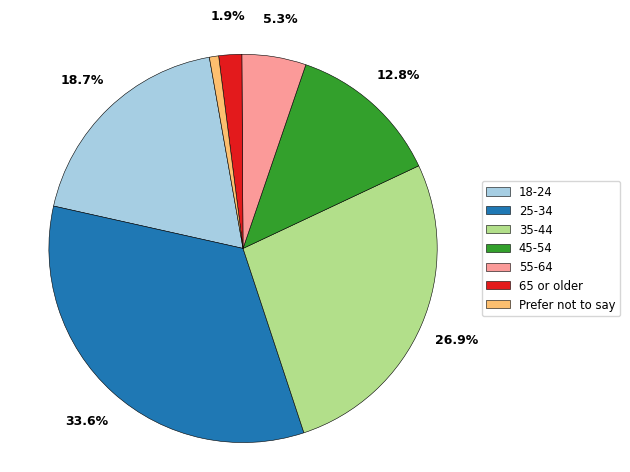

In [104]:
labels = age_groups.index.tolist()
size = age_groups['Proportion']


plt.Figure(figsize=(8, 6))

wedges, texts, autotexts = plt.pie(
    size, 
    autopct='%1.1f%%',
    pctdistance=1.2, 
    startangle=100, 
    colors=plt.cm.Paired.colors,
    wedgeprops=wedge_properties,
    textprops=text_properties
)

# --- New code to hide a specific percentage ---
# Find the index of the label want to hide
try:
    pnts_index = labels.index('Prefer not to say')
    # Use the index to find the corresponding autotext and set it to an empty string
    autotexts[pnts_index].set_text('')
except ValueError:
    # This will prevent an error if the label is not found
    print("'Prefer not to say' label not found, no changes made.")


plt.axis('equal')

plt.legend(
    wedges, 
    labels,
    loc='center left',  
    bbox_to_anchor=(1, 0.5), 
    fontsize='small'
)

plt.tight_layout()

plt.savefig('charts/age_distribution_pie_chart.jpg', dpi=300, bbox_inches='tight', format='jpg')
plt.show()


### Insights on respondents' coding practices

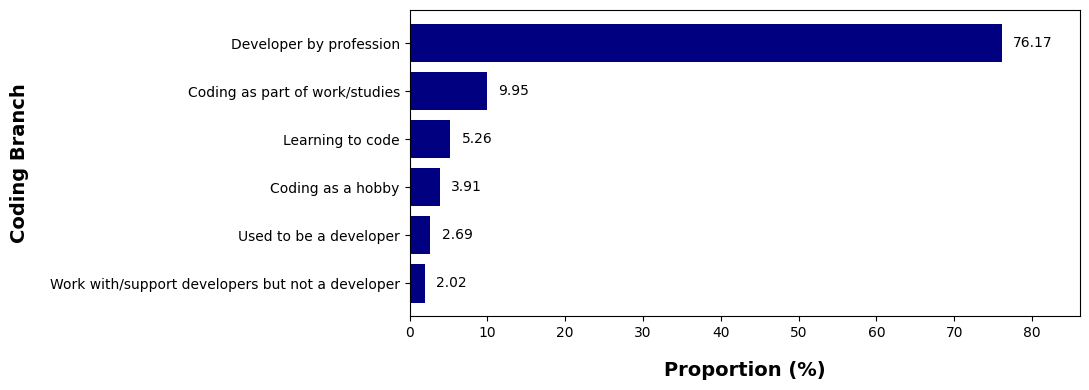

In [105]:
main_branch_new = main_branch_new.sort_values(by='Proportion', ascending=True)

fig, ax = plt.subplots(figsize=(11, 4))

fig = plt.barh(main_branch_new['MainBranch'], main_branch_new['Proportion'], color='navy')

ax.set_xlabel('Proportion (%)', fontsize=14, fontweight='bold', labelpad=15)
ax.set_ylabel('Coding Branch', fontsize=14, fontweight='bold', labelpad=15)
ax.bar_label(fig, padding=8)
ax.set_xlim(right=main_branch_new['Proportion'].max() + 10)

plt.tight_layout()

plt.savefig('charts/main_branch_bar_chart.jpg', dpi=300, bbox_inches='tight', format='jpg')
plt.show()

### Proportion of Developers by Industry:

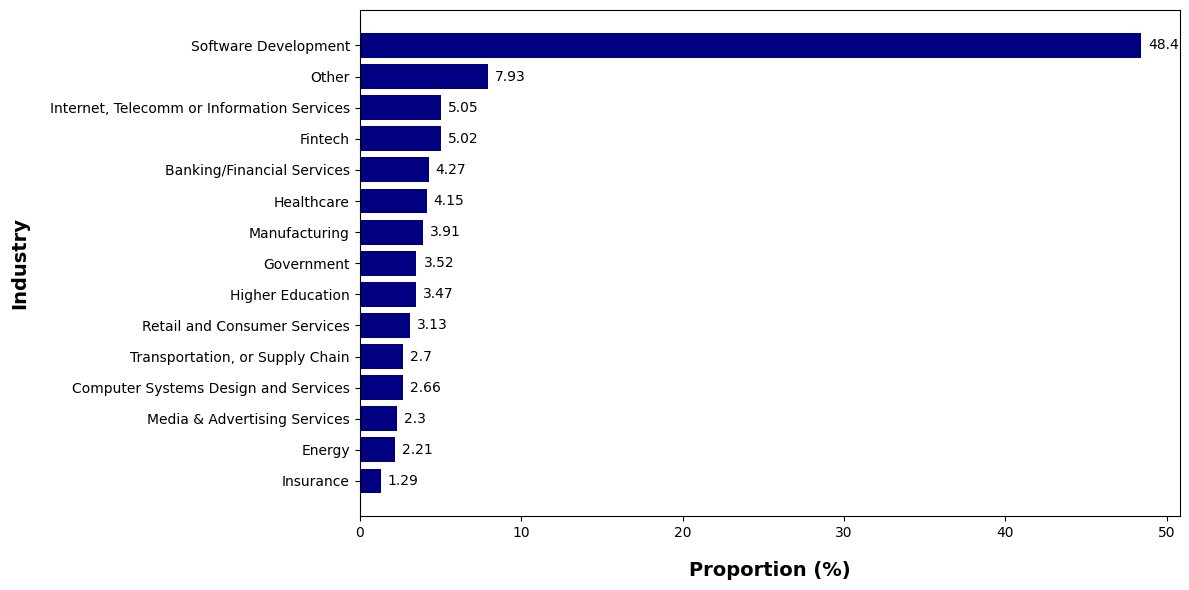

In [106]:
fig, ax = plt.subplots(figsize=(12, 6))

fig = plt.barh(
    industry['Industry'], 
    industry['Proportion'], 
    color='navy'
)

ax.set_xlabel('Proportion (%)', fontsize=14, fontweight='semibold', labelpad=15)
ax.set_ylabel('Industry', fontsize=14, fontweight='semibold', labelpad=15)
ax.bar_label(fig, padding=5, fontsize=10)
ax.invert_yaxis()

plt.tight_layout()

plt.savefig('charts/industry_bar_chart.jpg', dpi=300, bbox_inches='tight', format='jpg')
plt.show()


## AI & Coding Features

### Which methods does devs use to learn and code AI? ###

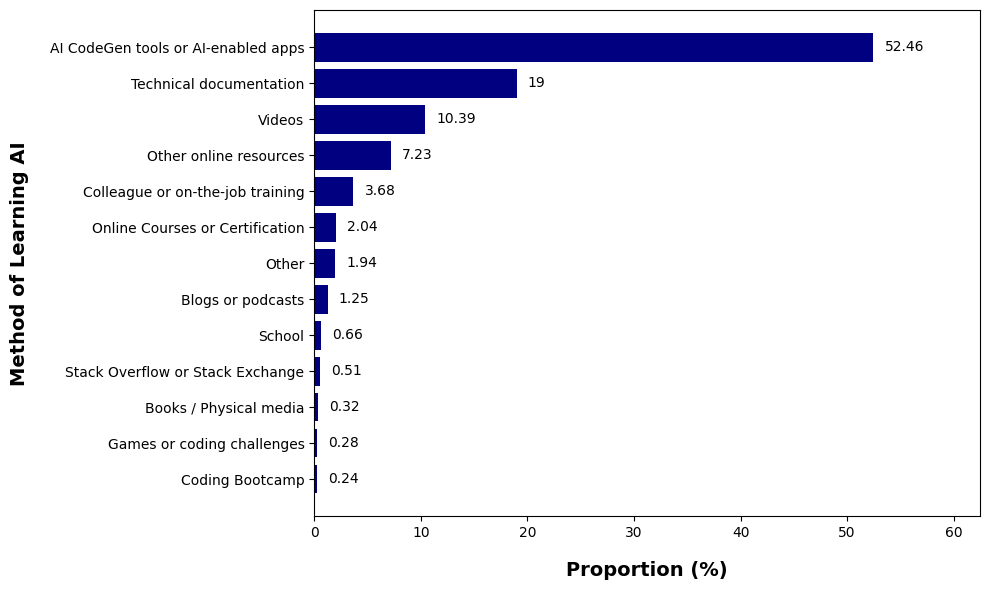

In [107]:
fig, ax = plt.subplots(figsize=(10, 6))

aihow_first_only = aihow_first_only.sort_values(by='Proportion', ascending=True)
fig = plt.barh(aihow_first_only['AILearnHow'], aihow_first_only['Proportion'], color='navy')

ax.set_xlabel('Proportion (%)', fontsize=14, fontweight='bold', labelpad=15)
ax.set_ylabel('Method of Learning AI', fontsize=14, fontweight='bold', labelpad=15)
ax.bar_label(fig, padding=8)
ax.set_xlim(right=aihow_first_only['Proportion'].max() + 10)

plt.tight_layout()

plt.savefig('charts/ai_learning_method_bar_chart.jpg', dpi=300, bbox_inches='tight', format='jpg')
plt.show()

### Proportion of Developers by Learning AI Use for Coding for career/personal goal

'Prefer not to say' label not found, no changes made.


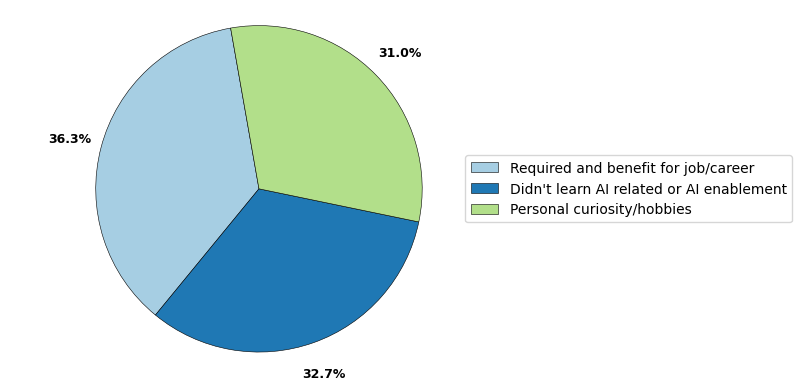

In [108]:
labels = new_learn_code['LearnCodeAI'].tolist()
size = new_learn_code['Proportion']


plt.figure(figsize=(8, 4))

wedges, texts, autotexts = plt.pie(
    size, 
    autopct='%1.1f%%',
    pctdistance=1.2, 
    startangle=100, 
    colors=plt.cm.Paired.colors,
    wedgeprops=wedge_properties,
    textprops=text_properties
)

# --- New code to hide a specific percentage ---
# Find the index of the label you want to hide
try:
    pnts_index = labels.index('Prefer not to say')
    # Use the index to find the corresponding autotext and set it to an empty string
    autotexts[pnts_index].set_text('')
except ValueError:
    # This will prevent an error if the label is not found
    print("'Prefer not to say' label not found, no changes made.")
# --- End of new code ---

plt.axis('equal')

plt.legend(
    wedges, 
    labels,
    loc='center left',  
    bbox_to_anchor=(0.9, 0.5), 
    fontsize='medium'
)

plt.tight_layout()

plt.savefig('charts/learn_code_ai_pie_chart.jpg', dpi=300, bbox_inches='tight', format='jpg')
plt.show()


### Proportion of Developers by Their Frequency of Using AI Tools


In [109]:
order = ['Daily', 'Weekly', 'Monthly or infrequently', 'Plan to use AI tools soon', 'Not plan to use AI tools']
ai_select_new['AISelect'] = pd.Categorical(ai_select_new['AISelect'], categories=order, ordered=True)
ai_select_new = ai_select_new.sort_values('AISelect', ascending=True)
ai_select_new 

,AISelect,Proportion
0,Daily,47.10
1,Weekly,17.67
3,Monthly or infrequently,13.72
4,Plan to use AI tools soon,5.33
2,Not plan to use AI tools,16.17


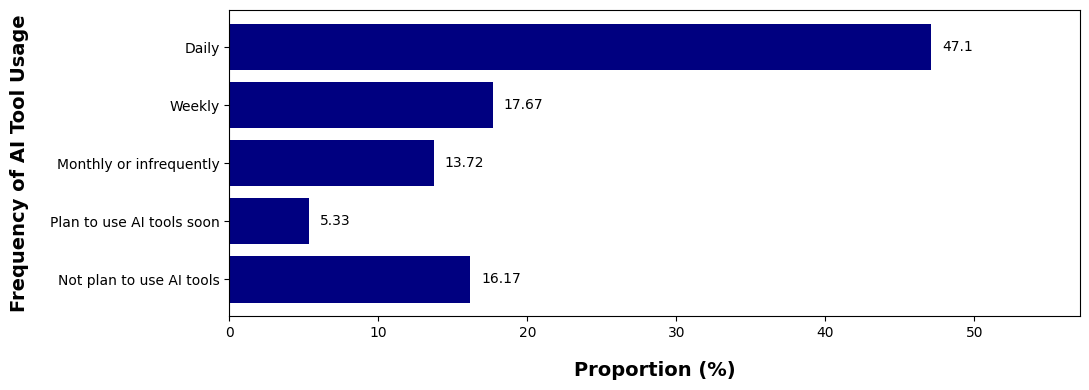

In [110]:
fig, ax = plt.subplots(figsize=(11, 4))

ai_select_new = ai_select_new.sort_values('AISelect', ascending=False)
fig = plt.barh(ai_select_new['AISelect'], ai_select_new['Proportion'], color='navy')

ax.set_xlabel('Proportion (%)', fontsize=14, fontweight='bold', labelpad=15)
ax.set_ylabel('Frequency of AI Tool Usage', fontsize=14, fontweight='bold', labelpad=15)
ax.bar_label(fig, padding=8)
ax.set_xlim(right=ai_select_new['Proportion'].max() + 10)

plt.tight_layout()

plt.savefig('charts/ai_tool_usage_frequency_bar_chart.jpg', dpi=300, bbox_inches='tight', format='jpg')
plt.show()

### Proportion of Developers by Their Sentiment Towards AI for Coding

In [111]:
order2 = ['Very favorable', 'Favorable', 'Indifferent', 'Unfavorable', 'Very unfavorable', 'Unsure']
ai_sent['AISent'] = pd.Categorical(ai_sent['AISent'], categories=order2, ordered=True)
ai_sent = ai_sent.sort_values('AISent', ascending=True)
ai_sent

,AISent,Proportion
1,Very favorable,22.94
0,Favorable,36.79
2,Indifferent,17.57
3,Unfavorable,10.82
4,Very unfavorable,9.62
5,Unsure,2.27


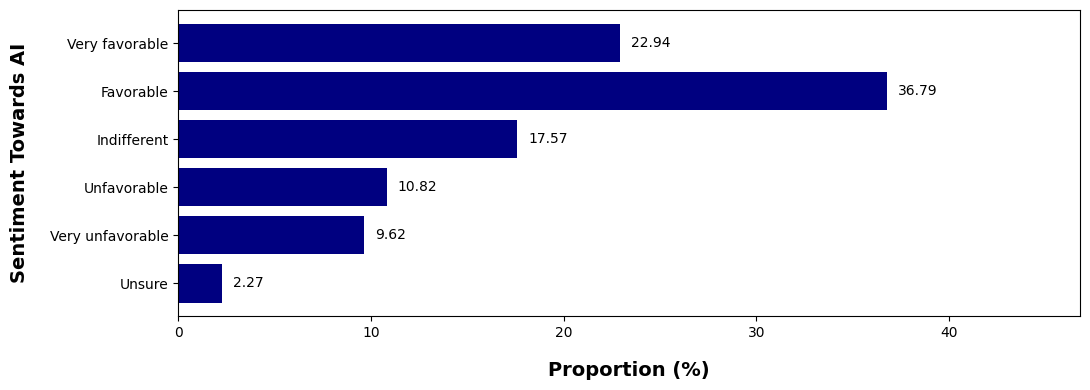

In [112]:
fig, ax = plt.subplots(figsize=(11, 4))

ai_sent = ai_sent.sort_values('AISent', ascending=False)
fig = plt.barh(ai_sent['AISent'], ai_sent['Proportion'], color='navy')

ax.set_xlabel('Proportion (%)', fontsize=14, fontweight='bold', labelpad=15)
ax.set_ylabel('Sentiment Towards AI', fontsize=14, fontweight='bold', labelpad=15)
ax.bar_label(fig, padding=8)
ax.set_xlim(right=ai_sent['Proportion'].max() + 10)

plt.tight_layout()

plt.savefig('charts/ai_sentiment_bar_chart.jpg', dpi=300, bbox_inches='tight', format='jpg')
plt.show()

### Proportion of Developers by Their Perception of AI Accuracy

In [113]:
order3 = ["Highly trust", "Somewhat trust", "Neither trust nor distrust", "Somewhat distrust", "Highly distrust"]
ai_acc['AIAcc'] = pd.Categorical(ai_acc['AIAcc'], categories=order3, ordered=True)
ai_acc = ai_acc.sort_values('AIAcc', ascending=True)
ai_acc

,AIAcc,Proportion
4,Highly trust,3.15
0,Somewhat trust,29.64
2,Neither trust nor distrust,21.51
1,Somewhat distrust,26.08
3,Highly distrust,19.62


'Prefer not to say' label not found, no changes made.


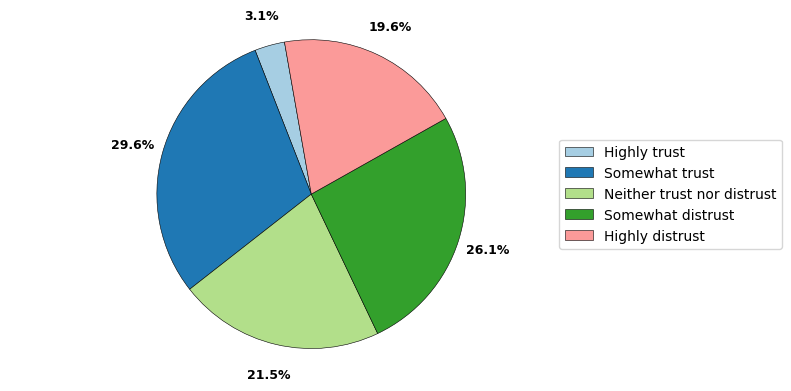

In [114]:
labels = ai_acc['AIAcc'].tolist()
size = ai_acc['Proportion']


plt.figure(figsize=(8, 4))

wedges, texts, autotexts = plt.pie(
    size, 
    autopct='%1.1f%%',
    pctdistance=1.2, 
    startangle=100, 
    colors=plt.cm.Paired.colors,
    wedgeprops=wedge_properties,
    textprops=text_properties
)

# --- New code to hide a specific percentage ---
# Find the index of the label you want to hide
try:
    pnts_index = labels.index('Prefer not to say')
    # Use the index to find the corresponding autotext and set it to an empty string
    autotexts[pnts_index].set_text('')
except ValueError:
    # This will prevent an error if the label is not found
    print("'Prefer not to say' label not found, no changes made.")
# --- End of new code ---

plt.axis('equal')

plt.legend(
    wedges, 
    labels,
    loc='center left',  
    bbox_to_anchor=(0.9, 0.5), 
    fontsize='medium'
)

plt.tight_layout()

plt.savefig('charts/ai_accuracy_pie_chart.jpg', dpi=300, bbox_inches='tight', format='jpg')
plt.show()

### Proportion of Developers by Their Perception of AI Complexity

In [115]:
order4 = ['Very well', 'Good, but not great', 'Neither good nor bad', 'Bad', 'Very poor', "Don't use AI tools for complex tasks / Don't know"]
ai_complex['AIComplex'] = pd.Categorical(ai_complex['AIComplex'], categories=order4, ordered=True)
ai_complex = ai_complex.sort_values('AIComplex', ascending=True)
ai_complex

,AIComplex,Proportion
5,Very well,4.38
0,"Good, but not great",25.19
4,Neither good nor bad,14.09
1,Bad,22.02
2,Very poor,17.56
3,Don't use AI tools for complex tasks / Don't know,16.77


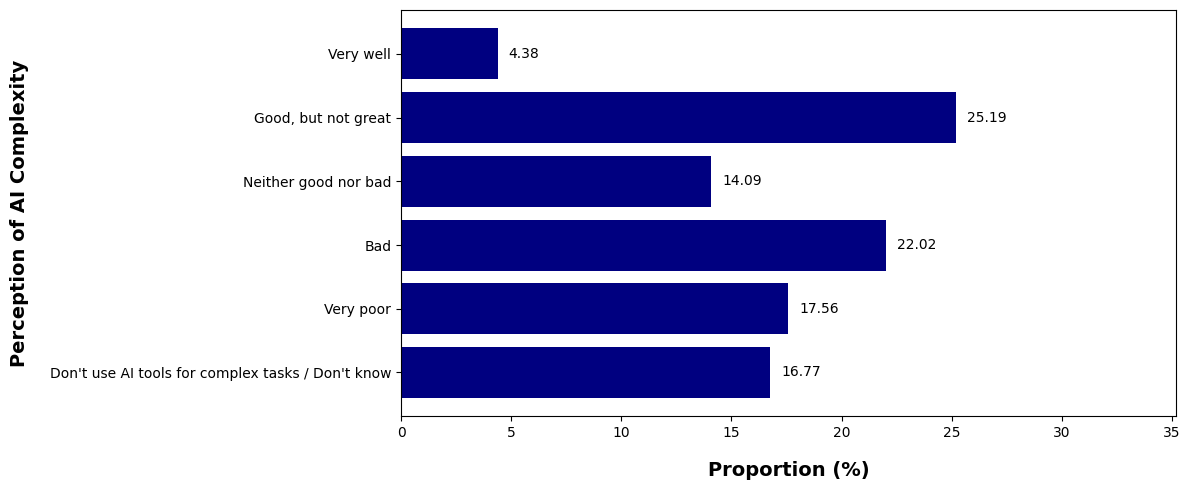

In [116]:
fig, ax = plt.subplots(figsize=(12, 5)) 

ai_complex = ai_complex.sort_values('AIComplex', ascending=False)
fig = plt.barh(ai_complex['AIComplex'], ai_complex['Proportion'], color='navy')
ax.set_xlabel('Proportion (%)', fontsize=14, fontweight='bold', labelpad=15)
ax.set_ylabel('Perception of AI Complexity', fontsize=14, fontweight='bold', labelpad=15)
ax.bar_label(fig, padding=8)
ax.set_xlim(right=ai_complex['Proportion'].max() + 10)

plt.tight_layout()

plt.savefig('charts/ai_complexity_bar_chart.jpg', dpi=300, bbox_inches='tight', format='jpg')
plt.show()

## Statistical Analysis

- AISent - AIAcc
- AISelect - AISent
- AISelect - AIAcc
- AIAcc - AIComplex

In [117]:
import scipy as scp
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import spearmanr, kendalltau

### Statistical Relationship between Perception of AI Accuracy & Sentiment Toward AI

In [118]:
order_aiacc = ["Highly distrust","Somewhat distrust", "Neither trust nor distrust", "Somewhat trust", "Highly trust"]

In [119]:
aisent_aiacc_table = pd.crosstab(demog_ai['AISent'], demog_ai['AIAcc']).reindex(index=order2, columns=order_aiacc)
print("Contingency Table for AISent and AIAcc:")
aisent_aiacc_table

Contingency Table for AISent and AIAcc:


AIAcc,Highly distrust,Somewhat distrust,Neither trust nor distrust,Somewhat trust,Highly trust
AISent,,,,,
Very favorable,254,794,1631,4070,867
Favorable,846,3117,3337,4811,139
Indifferent,994,2595,1546,699,18
Unfavorable,1680,1476,309,139,6
Very unfavorable,2582,450,118,53,5
Unsure,172,248,216,85,8


In [120]:
aisent_map = {
    'Very favorable': 5,
    'Favorable': 4,
    'Indifferent': 3,
    'Unfavorable': 2,
    'Very unfavorable': 1,
    'Unsure': 0
}
aiacc_map = {
    'Highly trust': 4,
    'Somewhat trust': 3,
    'Neither trust nor distrust': 2,
    'Somewhat distrust': 1,
    'Highly distrust': 0,
}

aisent_aiacc_table_mapped = demog_ai[['AISent', 'AIAcc']]
aisent_aiacc_table_mapped['AISent'] = aisent_aiacc_table_mapped['AISent'].map(aisent_map)
aisent_aiacc_table_mapped['AIAcc'] = aisent_aiacc_table_mapped['AIAcc'].map(aiacc_map)

aisent_aiacc_table_mapped['AISent'] = aisent_aiacc_table_mapped['AISent'].astype('Int64')
aisent_aiacc_table_mapped['AIAcc'] = aisent_aiacc_table_mapped['AIAcc'].astype('Int64')

In [121]:
aisent_aiacc_table_mapped.dtypes

AISent    Int64
AIAcc     Int64
dtype: object

As these two features are all ordinal, we change their values to integers and then condcut the Spearman's Rank Correlation Test on them.

In [122]:
correlation, p_value = spearmanr(
    aisent_aiacc_table_mapped['AISent'], 
    aisent_aiacc_table_mapped['AIAcc'],
    nan_policy='omit'
)
print(f"Spearman's rank correlation coefficient: {correlation:.3f}")
print(f"P-value: {p_value:.3f}")

Spearman's rank correlation coefficient: 0.608
P-value: 0.000


A Spearman's Rank Correlation Coefficient of 0.608 and a P-value of 0.0 means that these two features have a strong positive correlation. As developers tend to be more favorable toward AI, the more trust they have in its accuracy. Squaring the Spearman's Rank Correlation Coefficient gives the value of about 0.37, which implies that about 37% of the variance in the two features are explained by one another. 

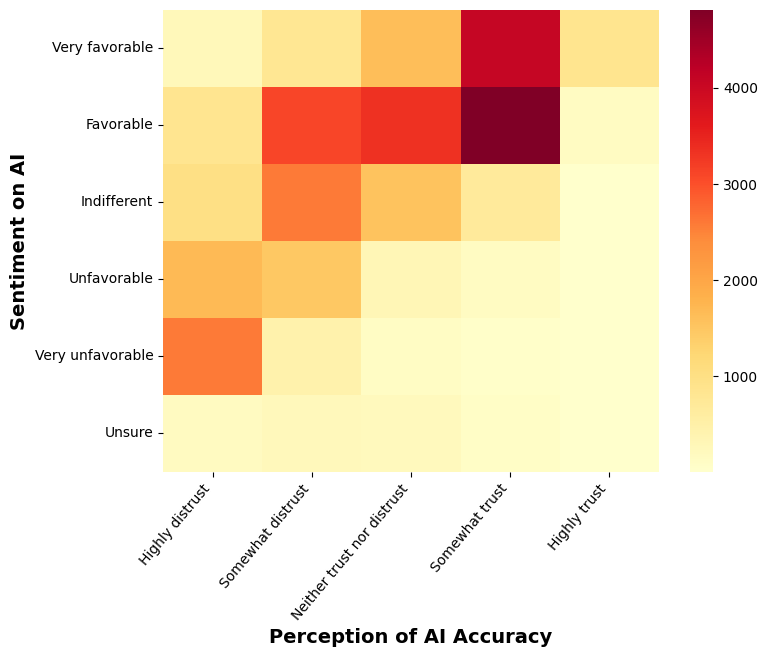

In [123]:
plt.figure(figsize=(8, 6))
sns.heatmap(aisent_aiacc_table, annot=False, fmt="d", cmap="YlOrRd")

plt.ylabel("Sentiment on AI", fontsize = 14, fontweight = 'bold')
plt.xlabel("Perception of AI Accuracy", fontsize = 14, fontweight = 'bold')

plt.xticks(rotation=50, ha="right")   # rotate x-axis labels
plt.yticks(rotation= 360)

plt.savefig('charts/aisent_aiacc_heatmap.jpg', dpi=300, bbox_inches='tight', format='jpg')
plt.show()

### Statistical Relationship Between Perception of AI Complexity & AI Accuracy

In [124]:
aicomplex_aiacc_table = pd.crosstab(demog_ai['AIComplex'], demog_ai['AIAcc']).reindex(index=order4, columns=order_aiacc)
print("Contingency Table for AIComplex and AIAcc:")
aicomplex_aiacc_table

Contingency Table for AIComplex and AIAcc:


AIAcc,Highly distrust,Somewhat distrust,Neither trust nor distrust,Somewhat trust,Highly trust
AIComplex,,,,,
Very well,19,38,130,654,595
"Good, but not great",171,877,1838,5141,327
Neither good nor bad,191,912,1864,1665,48
Bad,871,3005,1890,1534,21
Very poor,2837,2096,579,318,12
Don't use AI tools for complex tasks / Don't know,2436,1735,829,527,34


In [125]:
demog_ai['AIComplex'].value_counts()

AIComplex
Good, but not great                                  8384
Bad                                                  7328
Very poor                                            5844
Don't use AI tools for complex tasks / Don't know    5582
Neither good nor bad                                 4688
Very well                                            1457
Name: count, dtype: int64

In [126]:
ai_complex_int_mapping = {
    'Very well': 5,
    'Good, but not great': 4,
    'Neither good nor bad': 3,
    'Bad': 2,
    'Very poor': 1,
    "Don't use AI tools for complex tasks / Don't know": 0
}

aicomplex_aiacc_table_mapped = demog_ai[['AIAcc', 'AIComplex']]
aicomplex_aiacc_table_mapped['AIAcc'] = aicomplex_aiacc_table_mapped['AIAcc'].map(aiacc_map)
aicomplex_aiacc_table_mapped['AIComplex'] = aicomplex_aiacc_table_mapped['AIComplex'].map(ai_complex_int_mapping)

aicomplex_aiacc_table_mapped['AIAcc'] = aicomplex_aiacc_table_mapped['AIAcc'].astype('Int64')
aicomplex_aiacc_table_mapped['AIComplex'] = aicomplex_aiacc_table_mapped['AIComplex'].astype('Int64')

In [127]:
correlation, p_value = spearmanr(
    aicomplex_aiacc_table_mapped['AIComplex'], 
    aicomplex_aiacc_table_mapped['AIAcc'],
    nan_policy='omit'
)
print(f"Spearman's rank correlation coefficient: {correlation:.3f}")
print(f"P-value: {p_value:.3f}")

Spearman's rank correlation coefficient: 0.623
P-value: 0.000


A Spearman's Rank Correlation Coefficient of 0.623 and a P-value of 0.0 indicate a strong positive correlation between these two features. The higher the perception devs have of AI's ability to handle complex tasks, the more trust they have in its accuracy. Squaring the Spearman's Rank Correlation Coefficient gives the value of about 0.37, which implies that about 37% of the variance in the two features is explained by one another. 

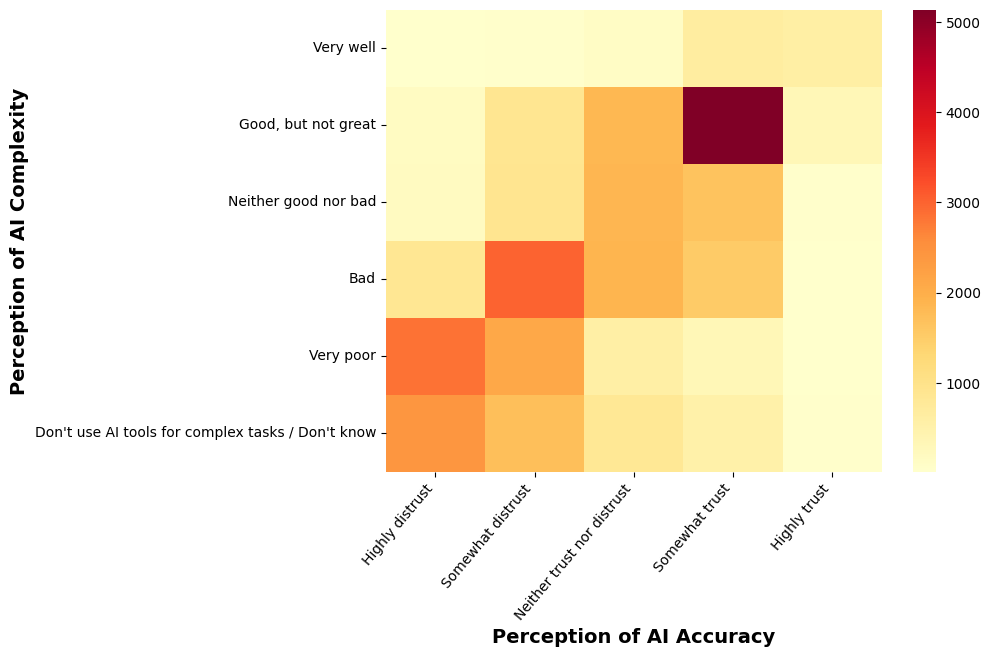

In [128]:
plt.figure(figsize=(8, 6))
sns.heatmap(aicomplex_aiacc_table, annot=False, fmt="d", cmap="YlOrRd")

plt.ylabel("Perception of AI Complexity", fontsize = 14, fontweight = 'bold')
plt.xlabel("Perception of AI Accuracy", fontsize = 14, fontweight = 'bold')

plt.xticks(rotation=50, ha="right") 
plt.yticks(rotation= 360)

plt.savefig("charts/aicomplex_aiacc_heatmap.jpg", bbox_inches='tight', format='jpg')
plt.show()

### The End